# Level-3 Goal-Directed Policy Persistence — Multi-Run (Research-Grade, Validity-Adjusted)

**Level-3 claim under test**
> The system maintains behaviour oriented toward an **internally represented target** across **goal omission**, **delay/partial observability**, and **interference**, and **resumes pursuit** after disruption. This must be **causally dependent** on the internal target pathway (validated via ablations).

### What this notebook implements (aligned to the Level-3 design section)
1) **Hidden-Goal Arena**: continuous 2D dynamics with process noise, bounded arena, randomised starts/goals.
2) **Goal cue window**: goal is revealed *briefly* (absolute target coordinates), then **fully removed**.
3) **Delay masking**: observation channels that allow stable localisation are masked for a variable window.
4) **Interference**: teleport or exogenous force during a variable window.
5) **Validity-adjusted evaluation**: **success is only counted after the “resume start” point** (after delay + interference), removing the “early success” loophole.
6) **Baselines + ablations**: competitive non-persistent baselines, plus interventions on the candidate’s goal/belief pathways.
7) **Multi-run stress testing**: multiple seeds × episodes with bootstrap confidence intervals and publishable plots.

**Interpretation discipline**
- Passing Level-3 here is **infrastructure validation** (goal persistence mechanism), not a claim of agency or subjective experience.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, Any, Optional, Tuple, List


## 0) Parameters (edit this cell)


In [ ]:
# --- Experiment scale ---
SEEDS = list(range(10))          # multi-run seeds
EPISODES_PER_SEED = 200          # per agent per seed
HORIZON = 140                    # steps per episode

# --- Arena dynamics ---
DT = 1.0
ALPHA_V = 0.85                   # velocity decay
BETA_A = 0.20                    # action gain
PROCESS_NOISE_STD = 0.01         # small but non-zero
ARENA_MIN = 0.0
ARENA_MAX = 1.0

# --- Goal / success ---
EPS_GOAL = 0.05                  # radius for "in goal region"
SUCCESS_STREAK = 5               # consecutive steps within EPS_GOAL (post-resume only)
MIN_START_GOAL_DIST = 0.40       # prevents trivial early successes

# --- Phase schedule ---
CUE_LEN = 8                      # steps where goal is visible
DELAY_LEN_RANGE = (18, 38)       # variable masking length
INTERFERE_LEN_RANGE = (10, 20)   # variable interference length

# Enforce interference occurs early enough to matter (but still after cue ends)
INTERFERE_START_RANGE = (18, 55) # sampled start time of interference (inclusive)
DELAY_START_RANGE = (12, 60)     # sampled start time of delay (inclusive)

# --- Delay masking ---
# We always provide velocity and a cue flag.
# Wall-distance sensors (left, right, bottom, top) enable localisation when not masked.
MASK_WALLS_DURING_DELAY = True   # if True: wall sensors are masked during delay

# --- Candidate controller gains ---
KP = 2.2
KD = 0.7
P_MEAS_BLEND = 0.85              # how strongly we correct p_hat from wall sensors

# --- Ablations ---
ENABLE_ABLATIONS = True
GOAL_SCRAMBLE_FAR_DIST = 0.60    # scrambled goal must be far from original

# --- Plotting / export ---
SAVE_FIGS = True
FIG_DIR = "level3_figures"


## 1) Environment — Hidden-Goal Arena (cue → delay masking → interference → resumption)


In [ ]:
@dataclass
class EpisodeSpec:
    goal: np.ndarray            # (2,) absolute goal position in [0,1]^2
    p0: np.ndarray              # (2,) start position
    v0: np.ndarray              # (2,) start velocity
    cue_len: int
    delay_start: int
    delay_end: int              # exclusive
    interfere_start: int
    interfere_end: int          # exclusive
    interfere_type: str         # "teleport" or "force"
    resume_start: int           # first time step after both delay and interference have ended
    ablate_t: int               # time where ablation (if enabled) is applied
    scrambled_goal: np.ndarray  # for goal-scramble ablation


@dataclass
class EnvConfig:
    horizon: int = HORIZON
    dt: float = DT
    alpha_v: float = ALPHA_V
    beta_a: float = BETA_A
    noise_std: float = PROCESS_NOISE_STD
    eps_goal: float = EPS_GOAL
    arena_min: float = ARENA_MIN
    arena_max: float = ARENA_MAX


def clip01(x: np.ndarray) -> np.ndarray:
    return np.clip(x, 0.0, 1.0)


def wall_sensors(p: np.ndarray) -> np.ndarray:
    # Distances to walls (left, right, bottom, top) in a unit square
    x, y = p
    return np.array([x, 1.0 - x, y, 1.0 - y], dtype=float)


def infer_position_from_walls(w: np.ndarray) -> np.ndarray:
    # Given wall distances, recover position (left=x, bottom=y)
    return np.array([w[0], w[2]], dtype=float)


def sample_goal_and_start(rng: np.random.Generator, min_dist: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Sample goal and start position with minimum separation
    for _ in range(10_000):
        goal = rng.uniform(0.1, 0.9, size=(2,))
        p0 = rng.uniform(0.1, 0.9, size=(2,))
        if np.linalg.norm(goal - p0) >= min_dist:
            v0 = rng.uniform(-0.05, 0.05, size=(2,))
            return goal, p0, v0
    # fallback (should be rare)
    goal = rng.uniform(0.1, 0.9, size=(2,))
    p0 = rng.uniform(0.1, 0.9, size=(2,))
    v0 = rng.uniform(-0.05, 0.05, size=(2,))
    return goal, p0, v0


def sample_scrambled_goal_far(rng: np.random.Generator, goal: np.ndarray, far_dist: float) -> np.ndarray:
    for _ in range(10_000):
        g2 = rng.uniform(0.1, 0.9, size=(2,))
        if np.linalg.norm(g2 - goal) >= far_dist:
            return g2
    return rng.uniform(0.1, 0.9, size=(2,))


def make_episode_spec(rng: np.random.Generator) -> EpisodeSpec:
    goal, p0, v0 = sample_goal_and_start(rng, MIN_START_GOAL_DIST)

    # Delay window
    delay_len = int(rng.integers(DELAY_LEN_RANGE[0], DELAY_LEN_RANGE[1] + 1))
    delay_start = int(rng.integers(DELAY_START_RANGE[0], DELAY_START_RANGE[1] + 1))
    delay_end = min(HORIZON, delay_start + delay_len)

    # Interference window
    interfere_len = int(rng.integers(INTERFERE_LEN_RANGE[0], INTERFERE_LEN_RANGE[1] + 1))
    interfere_start = int(rng.integers(INTERFERE_START_RANGE[0], INTERFERE_START_RANGE[1] + 1))
    interfere_end = min(HORIZON, interfere_start + interfere_len)

    interfere_type = "teleport" if rng.random() < 0.5 else "force"

    # Resume start is AFTER both delay and interference have ended
    resume_start = min(HORIZON - 1, max(delay_end, interfere_end))

    # Ablation time after cue ends but before resume_start (so post-resume metrics can detect collapse)
    ablate_t = int(np.clip(CUE_LEN + rng.integers(6, 14), CUE_LEN + 1, max(CUE_LEN + 1, resume_start - 2)))

    scrambled_goal = sample_scrambled_goal_far(rng, goal, GOAL_SCRAMBLE_FAR_DIST)

    return EpisodeSpec(
        goal=goal, p0=p0, v0=v0,
        cue_len=CUE_LEN,
        delay_start=delay_start, delay_end=delay_end,
        interfere_start=interfere_start, interfere_end=interfere_end,
        interfere_type=interfere_type,
        resume_start=resume_start,
        ablate_t=ablate_t,
        scrambled_goal=scrambled_goal
    )


class HiddenGoalArena:
    def __init__(self, cfg: EnvConfig):
        self.cfg = cfg
        self.rng = None
        self.spec: Optional[EpisodeSpec] = None
        self.t = 0
        self.p = None
        self.v = None
        self.force_vec = None

    def reset(self, rng: np.random.Generator, spec: EpisodeSpec) -> Dict[str, Any]:
        self.rng = rng
        self.spec = spec
        self.t = 0
        self.p = spec.p0.copy()
        self.v = spec.v0.copy()
        # fixed force direction for the episode (if used)
        theta = rng.uniform(0, 2*np.pi)
        self.force_vec = 0.06 * np.array([np.cos(theta), np.sin(theta)])
        return self.observe()

    def in_delay(self) -> bool:
        return self.spec.delay_start <= self.t < self.spec.delay_end

    def in_interference(self) -> bool:
        return self.spec.interfere_start <= self.t < self.spec.interfere_end

    def observe(self) -> Dict[str, Any]:
        # Always include velocity (noisy) and a cue flag.
        v_obs = self.v + self.rng.normal(0.0, 0.01, size=(2,))

        # Wall sensors are the main localisation aid (masked during delay if enabled).
        w = wall_sensors(self.p)
        if MASK_WALLS_DURING_DELAY and self.in_delay():
            w = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float)

        # Goal is only visible during the cue window (absolute goal coordinates).
        if self.t < self.spec.cue_len:
            goal_xy = self.spec.goal.copy()
            cue_flag = 1.0
        else:
            goal_xy = np.array([0.0, 0.0], dtype=float)
            cue_flag = 0.0

        return {
            "t": self.t,
            "v": v_obs,
            "walls": w,
            "goal_xy": goal_xy,
            "cue": cue_flag,
        }

    def step(self, action: np.ndarray) -> Tuple[Dict[str, Any], float, bool, Dict[str, Any]]:
        # Clip action
        a = np.clip(action, -1.0, 1.0)

        # Apply interference
        if self.in_interference():
            if self.spec.interfere_type == "teleport":
                # Teleport only on first interference step
                if self.t == self.spec.interfere_start:
                    self.p = self.rng.uniform(0.1, 0.9, size=(2,))
                    self.v = self.rng.uniform(-0.08, 0.08, size=(2,))
            else:
                self.v = self.v + self.force_vec

        # Dynamics update
        noise = self.rng.normal(0.0, self.cfg.noise_std, size=(2,))
        self.v = self.cfg.alpha_v * self.v + self.cfg.beta_a * a + noise
        self.p = clip01(self.p + self.v * self.cfg.dt)

        self.t += 1
        done = (self.t >= self.cfg.horizon)

        obs = self.observe() if not done else {
            "t": self.t,
            "v": self.v.copy(),
            "walls": wall_sensors(self.p),
            "goal_xy": np.array([0.0, 0.0]),
            "cue": 0.0
        }

        dist = float(np.linalg.norm(self.p - self.spec.goal))
        reward = -dist - 0.01 * float(np.sum(a*a))

        info = {
            "p": self.p.copy(),
            "v": self.v.copy(),
            "dist": dist,
            "in_delay": self.in_delay(),
            "in_interference": self.in_interference(),
        }
        return obs, reward, done, info


## 2) Agents — candidate + baselines + ablation wrappers


In [ ]:
class AgentBase:
    name: str = "base"
    def reset(self, spec: EpisodeSpec):
        pass
    def act(self, obs: Dict[str, Any]) -> np.ndarray:
        raise NotImplementedError


class Level3Candidate(AgentBase):
    # Minimal Level-3 instantiation:
    # - persistent goal register (stores absolute goal coordinates during cue window)
    # - belief state p_hat (dead-reckoning + measurement correction using wall sensors when available)
    # - goal-conditioned PD controller based on (goal_abs - p_hat, v_hat)
    def __init__(self, kp=KP, kd=KD, blend=P_MEAS_BLEND):
        self.name = "candidate_level3"
        self.kp = kp
        self.kd = kd
        self.blend = blend
        self.goal_abs = None
        self.p_hat = None
        self.v_hat = None
        self.t = 0

    def reset(self, spec: EpisodeSpec):
        self.goal_abs = None
        self.p_hat = np.array([0.5, 0.5], dtype=float)  # will correct quickly from walls
        self.v_hat = np.zeros(2, dtype=float)
        self.t = 0

    def _update_belief(self, obs: Dict[str, Any]):
        self.v_hat = obs["v"].copy()

        # Dead-reckoning prediction
        self.p_hat = clip01(self.p_hat + self.v_hat * DT)

        # Measurement correction from walls when available
        w = obs["walls"]
        if np.all(np.isfinite(w)):
            p_meas = infer_position_from_walls(w)
            self.p_hat = clip01((1.0 - self.blend) * self.p_hat + self.blend * p_meas)

        # Goal latch during cue window only
        if obs["cue"] > 0.5:
            self.goal_abs = obs["goal_xy"].copy()

    def act(self, obs: Dict[str, Any]) -> np.ndarray:
        self._update_belief(obs)
        self.t = int(obs["t"])

        if self.goal_abs is None:
            return -0.2 * self.v_hat

        err = (self.goal_abs - self.p_hat)
        a = self.kp * err - self.kd * self.v_hat
        return np.clip(a, -1.0, 1.0)


class ReactiveNoMemory(AgentBase):
    # Strong reactive baseline:
    # - Uses goal only when it is visible (cue window).
    # - After cue disappears, it cannot persist; it defaults to damping/homing.
    def __init__(self):
        self.name = "reactive_nomemory"
        self.p_hat = np.array([0.5, 0.5], dtype=float)
        self.v_hat = np.zeros(2, dtype=float)

    def reset(self, spec: EpisodeSpec):
        self.p_hat[:] = 0.5
        self.v_hat[:] = 0.0

    def act(self, obs: Dict[str, Any]) -> np.ndarray:
        self.v_hat = obs["v"].copy()
        w = obs["walls"]
        if np.all(np.isfinite(w)):
            self.p_hat = infer_position_from_walls(w)

        if obs["cue"] > 0.5:
            goal = obs["goal_xy"]
            err = goal - self.p_hat
            a = 2.2 * err - 0.7 * self.v_hat
            return np.clip(a, -1.0, 1.0)

        a = -0.3 * self.v_hat + 0.3 * (np.array([0.5, 0.5]) - self.p_hat)
        return np.clip(a, -1.0, 1.0)


class HeadingScript(AgentBase):
    # Pseudo-goal baseline:
    # - During cue, computes an initial desired heading, then persists heading open-loop.
    # - Looks goal-directed early, but fails after teleport or large detours.
    def __init__(self):
        self.name = "heading_script"
        self.dir = np.zeros(2, dtype=float)

    def reset(self, spec: EpisodeSpec):
        self.dir[:] = 0.0

    def act(self, obs: Dict[str, Any]) -> np.ndarray:
        if obs["cue"] > 0.5 and np.all(np.isfinite(obs["walls"])):
            p = infer_position_from_walls(obs["walls"])
            g = obs["goal_xy"]
            d = g - p
            n = np.linalg.norm(d) + 1e-8
            self.dir = d / n

        return np.clip(0.8 * self.dir - 0.15 * obs["v"], -1.0, 1.0)


class DefaultAttractor(AgentBase):
    # Always goes to the arena center (ignores target identity).
    def __init__(self):
        self.name = "default_attractor"
        self.p_hat = np.array([0.5, 0.5], dtype=float)

    def reset(self, spec: EpisodeSpec):
        self.p_hat[:] = 0.5

    def act(self, obs: Dict[str, Any]) -> np.ndarray:
        w = obs["walls"]
        if np.all(np.isfinite(w)):
            self.p_hat = infer_position_from_walls(w)
        err = np.array([0.5, 0.5]) - self.p_hat
        a = 1.8 * err - 0.6 * obs["v"]
        return np.clip(a, -1.0, 1.0)


# --- Ablation wrappers (applied only to candidate) ---
class AblateGoalScramble(Level3Candidate):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.name = "candidate_ablate_goal_scramble"
        self._scrambled_goal = None
        self._ablate_t = None

    def reset(self, spec: EpisodeSpec):
        super().reset(spec)
        self._scrambled_goal = spec.scrambled_goal.copy()
        self._ablate_t = spec.ablate_t

    def act(self, obs: Dict[str, Any]) -> np.ndarray:
        self._update_belief(obs)
        t = int(obs["t"])
        if (self.goal_abs is not None) and (t == self._ablate_t):
            self.goal_abs = self._scrambled_goal.copy()
        self.t = t
        if self.goal_abs is None:
            return -0.2 * self.v_hat
        err = (self.goal_abs - self.p_hat)
        a = self.kp * err - self.kd * self.v_hat
        return np.clip(a, -1.0, 1.0)


class AblateGoalDecouple(Level3Candidate):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.name = "candidate_ablate_goal_decouple"

    def act(self, obs: Dict[str, Any]) -> np.ndarray:
        self._update_belief(obs)
        if obs["cue"] < 0.5:
            a = -0.3 * self.v_hat + 0.3 * (np.array([0.5, 0.5]) - self.p_hat)
            return np.clip(a, -1.0, 1.0)

        if self.goal_abs is None:
            return -0.2 * self.v_hat
        err = (self.goal_abs - self.p_hat)
        a = self.kp * err - self.kd * self.v_hat
        return np.clip(a, -1.0, 1.0)


class AblateBeliefReset(Level3Candidate):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.name = "candidate_ablate_belief_reset"
        self._ablate_t = None

    def reset(self, spec: EpisodeSpec):
        super().reset(spec)
        self._ablate_t = spec.resume_start  # reset belief right at resume point

    def act(self, obs: Dict[str, Any]) -> np.ndarray:
        self._update_belief(obs)
        t = int(obs["t"])
        if t == self._ablate_t:
            self.p_hat = np.array([0.5, 0.5], dtype=float)
        if self.goal_abs is None:
            return -0.2 * self.v_hat
        err = (self.goal_abs - self.p_hat)
        a = self.kp * err - self.kd * self.v_hat
        return np.clip(a, -1.0, 1.0)


## 3) Validity-adjusted metrics (fixes the Level-3 ‘early success’ loophole)


In [ ]:
def compute_post_resume_success(dist: np.ndarray, resume_start: int, eps: float, streak: int) -> bool:
    # Success is counted ONLY if the agent enters the goal region for 'streak' consecutive steps
    # at some time t >= resume_start. Any early goal contact before resume_start is ignored.
    run = 0
    for t in range(resume_start, len(dist)):
        if dist[t] <= eps:
            run += 1
            if run >= streak:
                return True
        else:
            run = 0
    return False


def resumption_latency(dist: np.ndarray, resume_start: int, delta: float = 0.10, sustain: int = 4) -> int:
    # Steps from resume_start until sustained improvement of at least 'delta' vs dist at resume_start.
    d0 = dist[resume_start]
    target = d0 - delta
    if target <= 0:
        return 0
    for t in range(resume_start, len(dist) - sustain):
        window = dist[t:t+sustain]
        if np.all(window <= target):
            return t - resume_start
    return len(dist) - 1 - resume_start


def persistence_ratio(dist: np.ndarray, resume_start: int, tol: float = 1e-4) -> float:
    # Fraction of post-resume steps where distance decreases (progress toward goal).
    if resume_start >= len(dist) - 2:
        return 0.0
    dec = 0
    total = 0
    for t in range(resume_start, len(dist) - 1):
        total += 1
        if dist[t+1] < dist[t] - tol:
            dec += 1
    return dec / max(1, total)


def delay_progress(dist: np.ndarray, delay_start: int, delay_end: int) -> float:
    # Mean signed progress (dist[t] - dist[t+1]) during the delay window.
    ds = int(np.clip(delay_start, 0, len(dist)-2))
    de = int(np.clip(delay_end, ds+1, len(dist)-1))
    diffs = dist[ds:de] - dist[ds+1:de+1]
    return float(np.mean(diffs)) if len(diffs) > 0 else 0.0


def drift_after_resume(dist: np.ndarray, resume_start: int) -> float:
    # Final distance minus distance at resume_start. Positive indicates drift away post-resume.
    if resume_start >= len(dist):
        return float("nan")
    return float(dist[-1] - dist[resume_start])


## 4) Rollout runner + multi-run evaluation


In [ ]:
def run_episode(env: HiddenGoalArena, rng: np.random.Generator, agent: AgentBase, spec: EpisodeSpec) -> Dict[str, Any]:
    obs = env.reset(rng, spec)
    agent.reset(spec)

    ps = []
    dists = []
    flags = []  # (in_delay, in_interference)

    for _ in range(env.cfg.horizon):
        a = agent.act(obs)
        obs, r, done, info = env.step(a)
        ps.append(info["p"])
        dists.append(info["dist"])
        flags.append((info["in_delay"], info["in_interference"]))
        if done:
            break

    return {
        "ps": np.asarray(ps),
        "dist": np.asarray(dists),
        "spec": spec,
        "flags": np.asarray(flags, dtype=bool),
    }


def bootstrap_ci(x: np.ndarray, iters: int = 1500, alpha: float = 0.05, rng: Optional[np.random.Generator] = None):
    if rng is None:
        rng = np.random.default_rng(0)
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return (np.nan, np.nan)
    means = []
    for _ in range(iters):
        samp = rng.choice(x, size=len(x), replace=True)
        means.append(float(np.mean(samp)))
    means = np.sort(np.asarray(means))
    lo = float(np.quantile(means, alpha/2))
    hi = float(np.quantile(means, 1 - alpha/2))
    return lo, hi


def evaluate_agents():
    cfg = EnvConfig()
    env = HiddenGoalArena(cfg)

    agents: List[AgentBase] = [
        Level3Candidate(),
        ReactiveNoMemory(),
        HeadingScript(),
        DefaultAttractor(),
    ]

    if ENABLE_ABLATIONS:
        agents += [
            AblateGoalScramble(),
            AblateGoalDecouple(),
            AblateBeliefReset(),
        ]

    all_rows = []
    traces = {}

    for seed in SEEDS:
        rng = np.random.default_rng(seed)

        for agent in agents:
            for ep in range(EPISODES_PER_SEED):
                spec = make_episode_spec(rng)
                out = run_episode(env, rng, agent, spec)
                dist = out["dist"]
                rs = spec.resume_start

                row = {
                    "seed": seed,
                    "agent": agent.name,
                    "success_post": float(compute_post_resume_success(dist, rs, EPS_GOAL, SUCCESS_STREAK)),
                    "resume_latency": float(resumption_latency(dist, rs)),
                    "persist_ratio": float(persistence_ratio(dist, rs)),
                    "delay_progress": float(delay_progress(dist, spec.delay_start, spec.delay_end)),
                    "drift": float(drift_after_resume(dist, rs)),
                    "resume_start": rs,
                    "delay_len": int(spec.delay_end - spec.delay_start),
                    "interfere_len": int(spec.interfere_end - spec.interfere_start),
                    "interfere_type": spec.interfere_type,
                    "ablate_t": int(spec.ablate_t),
                }
                all_rows.append(row)

                key = (seed, agent.name)
                if key not in traces and ep == 0:
                    traces[key] = out

    df = pd.DataFrame(all_rows)
    return df, traces


df, traces = evaluate_agents()

summary = []
rng_ci = np.random.default_rng(123)

for agent, g in df.groupby("agent"):
    row = {"agent": agent}
    for metric in ["success_post", "resume_latency", "persist_ratio", "delay_progress", "drift"]:
        vals = g[metric].to_numpy()
        row[f"{metric}_mean"] = float(np.mean(vals))
        lo, hi = bootstrap_ci(vals, rng=rng_ci)
        row[f"{metric}_lo"] = lo
        row[f"{metric}_hi"] = hi
    summary.append(row)

summary_df = pd.DataFrame(summary).sort_values("success_post_mean", ascending=False)
summary_df


,agent,success_post_mean,success_post_lo,success_post_hi,resume_latency_mean,resume_latency_lo,resume_latency_hi,persist_ratio_mean,persist_ratio_lo,persist_ratio_hi,delay_progress_mean,delay_progress_lo,delay_progress_hi,drift_mean,drift_lo,drift_hi
0,candidate_ablate_belief_reset,1.0000,1.000000,1.0000,12.6210,11.725375,13.529462,0.513521,0.512082,0.514968,-0.004274,-0.004484,-0.004080,-0.146940,-0.151683,-0.142408
3,candidate_level3,1.0000,1.000000,1.0000,4.4405,3.764237,5.121912,0.505112,0.503568,0.506654,-0.001998,-0.002214,-0.001777,-0.061313,-0.065720,-0.056953
1,candidate_ablate_goal_decouple,0.0270,0.020000,0.0340,34.5850,33.252650,35.973575,0.507712,0.505160,0.510343,-0.000049,-0.000444,0.000369,-0.073690,-0.082866,-0.065070
6,reactive_nomemory,0.0260,0.019238,0.0335,17.5990,16.403800,18.780500,0.530712,0.528145,0.533136,-0.007129,-0.007676,-0.006537,-0.254198,-0.266918,-0.241288
4,default_attractor,0.0055,0.002500,0.0090,28.6160,27.007513,30.192937,0.504804,0.503199,0.506367,-0.007077,-0.007494,-0.006591,-0.154313,-0.165340,-0.144044
2,candidate_ablate_goal_scramble,0.0000,0.000000,0.0000,67.5310,66.589462,68.426288,0.498354,0.496735,0.499968,-0.001278,-0.001693,-0.000828,0.024758,0.020157,0.029524
5,heading_script,0.0000,0.000000,0.0000,70.4495,69.750625,71.156262,0.013578,0.010687,0.016700,-0.000412,-0.000571,-0.000258,0.002758,-0.000350,0.006061


## 5) Results summary + quick diagnostics


In [ ]:
display(summary_df)

print("\nPer-agent overview (mean ± bootstrap CI):")
for _, r in summary_df.iterrows():
    a = r["agent"]
    print(
        f"- {a:28s}  success_post={r['success_post_mean']:.3f} "
        f"[{r['success_post_lo']:.3f},{r['success_post_hi']:.3f}]"
        f" | resume_latency={r['resume_latency_mean']:.1f}"
        f" | persist_ratio={r['persist_ratio_mean']:.2f}"
        f" | delay_progress={r['delay_progress_mean']:.4f}"
        f" | drift={r['drift_mean']:.3f}"
    )

# Sanity: show how often ablation triggers relative to resume_start (should be < resume_start)
if ENABLE_ABLATIONS:
    sub = df[df["agent"] == "candidate_ablate_goal_scramble"]
    print("\nAblation timing sanity (scramble): mean(ablate_t), mean(resume_start)")
    print(float(np.mean(sub["ablate_t"])), float(np.mean(sub["resume_start"])))


,agent,success_post_mean,success_post_lo,success_post_hi,resume_latency_mean,resume_latency_lo,resume_latency_hi,persist_ratio_mean,persist_ratio_lo,persist_ratio_hi,delay_progress_mean,delay_progress_lo,delay_progress_hi,drift_mean,drift_lo,drift_hi
0,candidate_ablate_belief_reset,1.0000,1.000000,1.0000,12.6210,11.725375,13.529462,0.513521,0.512082,0.514968,-0.004274,-0.004484,-0.004080,-0.146940,-0.151683,-0.142408
3,candidate_level3,1.0000,1.000000,1.0000,4.4405,3.764237,5.121912,0.505112,0.503568,0.506654,-0.001998,-0.002214,-0.001777,-0.061313,-0.065720,-0.056953
1,candidate_ablate_goal_decouple,0.0270,0.020000,0.0340,34.5850,33.252650,35.973575,0.507712,0.505160,0.510343,-0.000049,-0.000444,0.000369,-0.073690,-0.082866,-0.065070
6,reactive_nomemory,0.0260,0.019238,0.0335,17.5990,16.403800,18.780500,0.530712,0.528145,0.533136,-0.007129,-0.007676,-0.006537,-0.254198,-0.266918,-0.241288
4,default_attractor,0.0055,0.002500,0.0090,28.6160,27.007513,30.192937,0.504804,0.503199,0.506367,-0.007077,-0.007494,-0.006591,-0.154313,-0.165340,-0.144044
2,candidate_ablate_goal_scramble,0.0000,0.000000,0.0000,67.5310,66.589462,68.426288,0.498354,0.496735,0.499968,-0.001278,-0.001693,-0.000828,0.024758,0.020157,0.029524
5,heading_script,0.0000,0.000000,0.0000,70.4495,69.750625,71.156262,0.013578,0.010687,0.016700,-0.000412,-0.000571,-0.000258,0.002758,-0.000350,0.006061



Per-agent overview (mean ± bootstrap CI):
- candidate_ablate_belief_reset  success_post=1.000 [1.000,1.000] | resume_latency=12.6 | persist_ratio=0.51 | delay_progress=-0.0043 | drift=-0.147
- candidate_level3              success_post=1.000 [1.000,1.000] | resume_latency=4.4 | persist_ratio=0.51 | delay_progress=-0.0020 | drift=-0.061
- candidate_ablate_goal_decouple  success_post=0.027 [0.020,0.034] | resume_latency=34.6 | persist_ratio=0.51 | delay_progress=-0.0000 | drift=-0.074
- reactive_nomemory             success_post=0.026 [0.019,0.034] | resume_latency=17.6 | persist_ratio=0.53 | delay_progress=-0.0071 | drift=-0.254
- default_attractor             success_post=0.005 [0.003,0.009] | resume_latency=28.6 | persist_ratio=0.50 | delay_progress=-0.0071 | drift=-0.154
- candidate_ablate_goal_scramble  success_post=0.000 [0.000,0.000] | resume_latency=67.5 | persist_ratio=0.50 | delay_progress=-0.0013 | drift=0.025
- heading_script                success_post=0.000 [0.000,0.000] |

## 6) Plots (publishable figures)


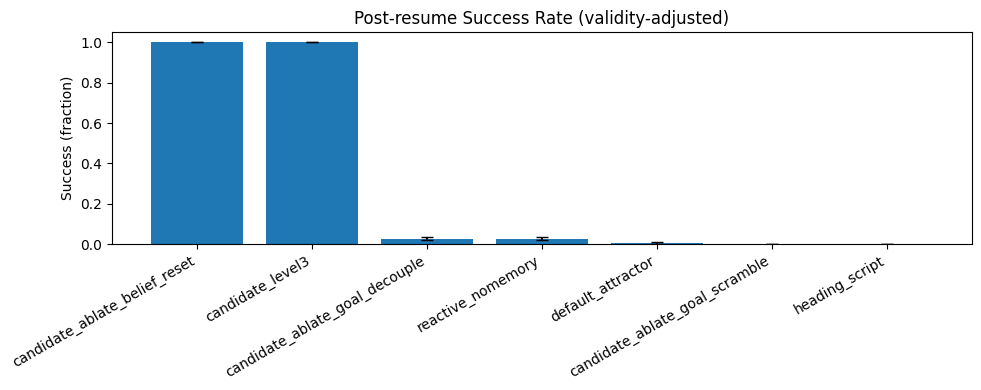

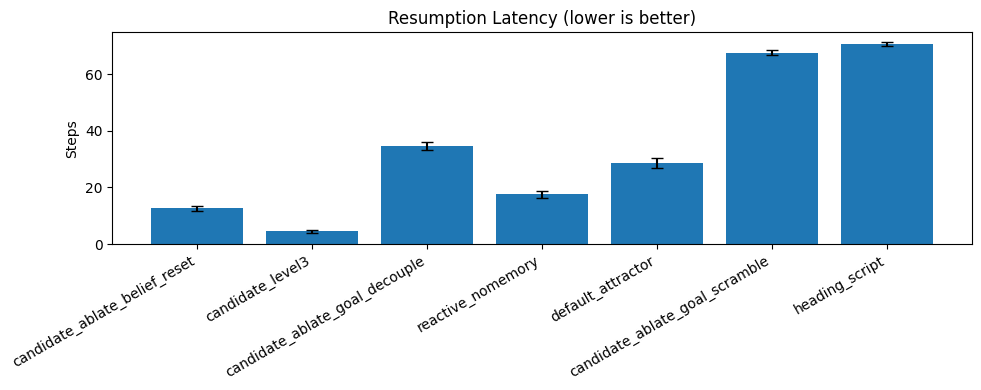

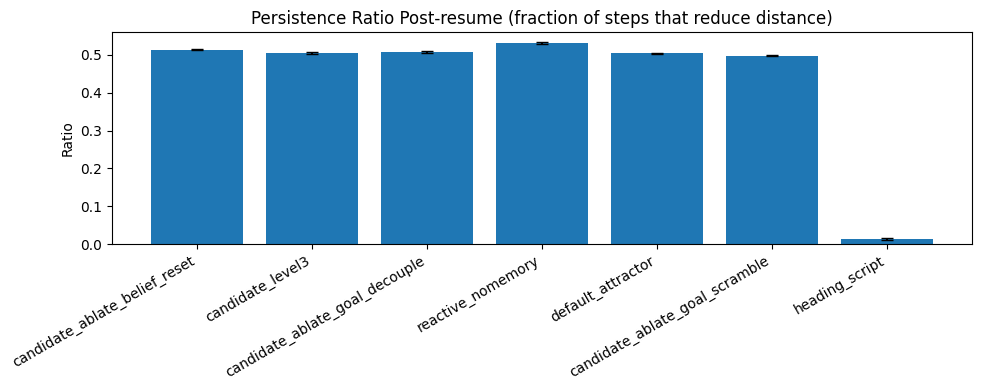

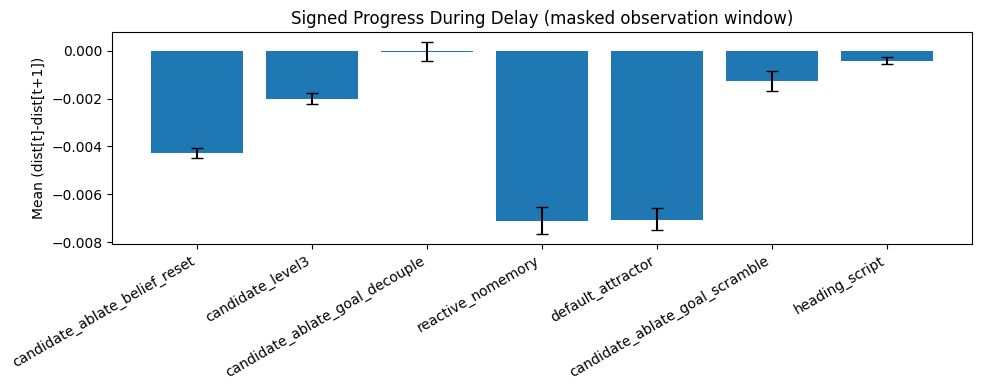

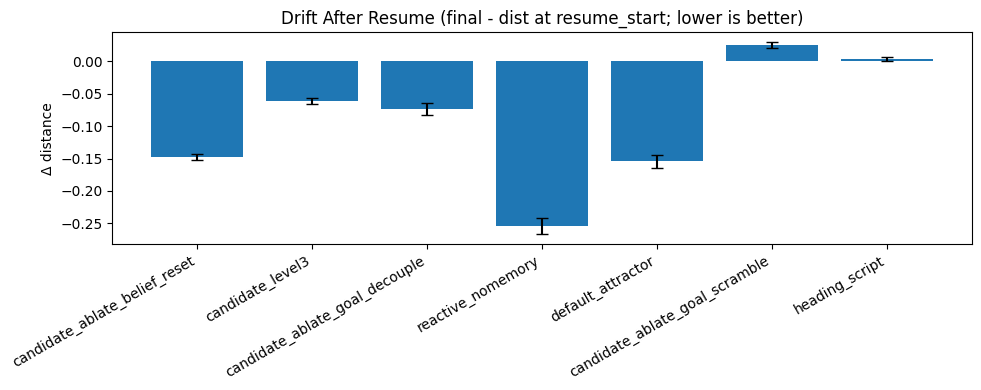

In [ ]:
import os
os.makedirs(FIG_DIR, exist_ok=True)

def bar_ci(summary_df: pd.DataFrame, metric: str, title: str, ylabel: str, fname: str):
    agents = summary_df["agent"].tolist()
    means = summary_df[f"{metric}_mean"].to_numpy()
    lo = summary_df[f"{metric}_lo"].to_numpy()
    hi = summary_df[f"{metric}_hi"].to_numpy()
    yerr = np.vstack([means - lo, hi - means])

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(agents)), means, yerr=yerr, capsize=4)
    plt.xticks(np.arange(len(agents)), agents, rotation=30, ha="right")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(os.path.join(FIG_DIR, fname), dpi=160)
    plt.show()


bar_ci(summary_df, "success_post",
       "Post-resume Success Rate (validity-adjusted)",
       "Success (fraction)", "fig_success_post.png")

bar_ci(summary_df, "resume_latency",
       "Resumption Latency (lower is better)",
       "Steps", "fig_resumption_latency.png")

bar_ci(summary_df, "persist_ratio",
       "Persistence Ratio Post-resume (fraction of steps that reduce distance)",
       "Ratio", "fig_persistence_ratio.png")

bar_ci(summary_df, "delay_progress",
       "Signed Progress During Delay (masked observation window)",
       "Mean (dist[t]-dist[t+1])", "fig_delay_progress.png")

bar_ci(summary_df, "drift",
       "Drift After Resume (final - dist at resume_start; lower is better)",
       "Δ distance", "fig_drift.png")


## 7) Example traces (distance-to-goal with phase overlays)


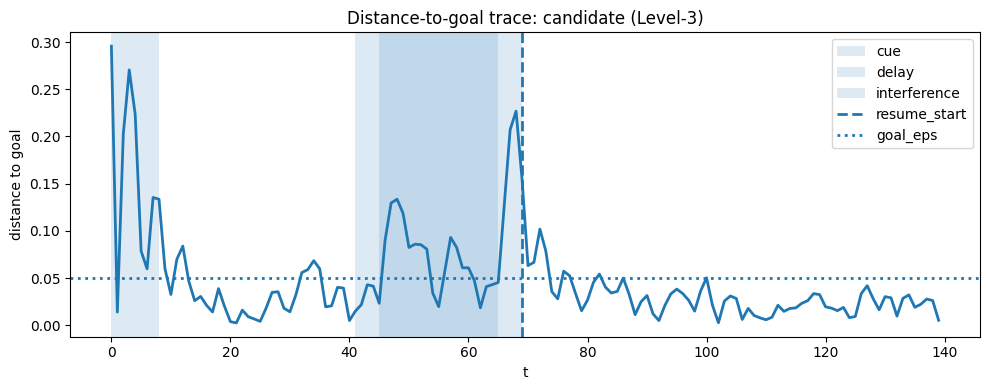

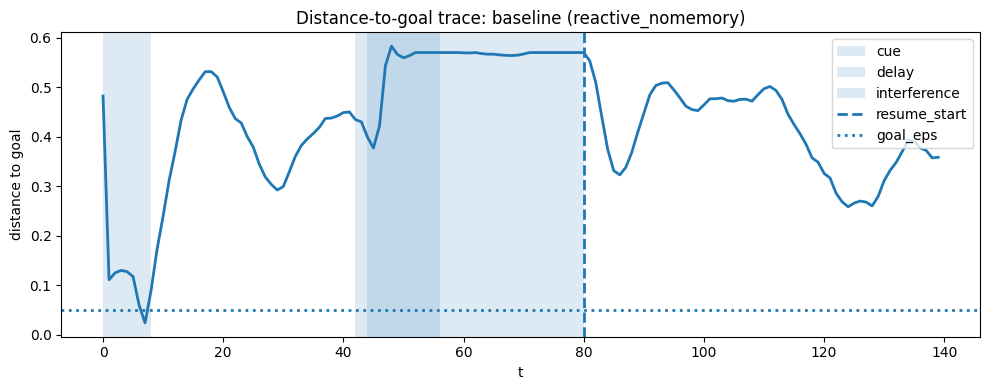

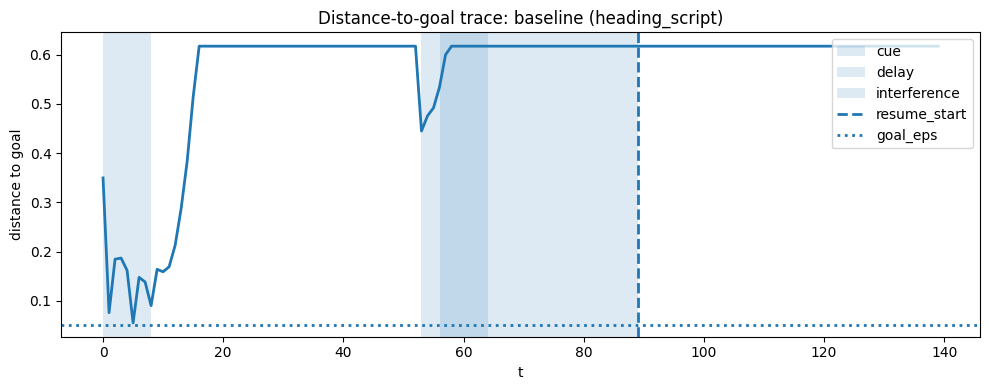

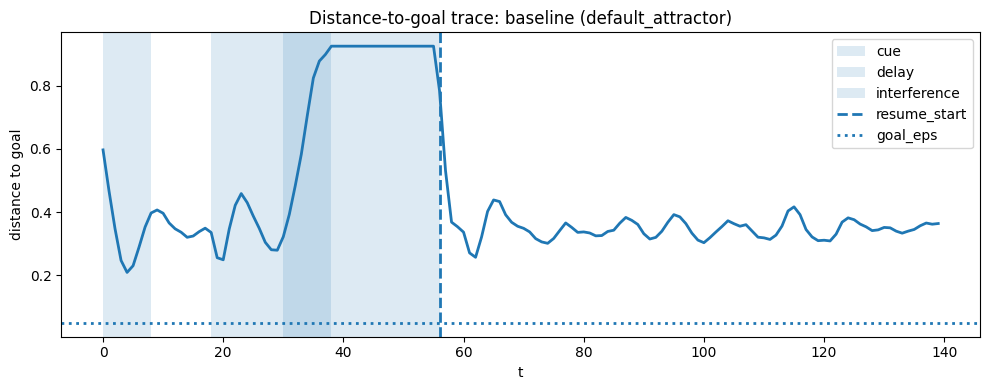

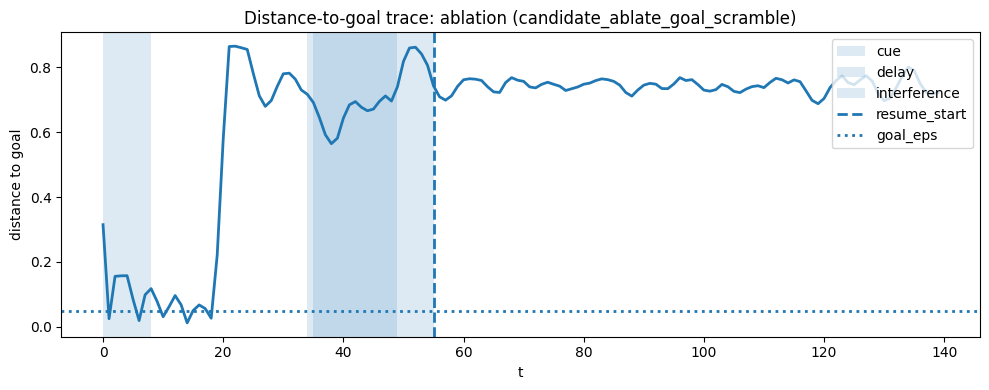

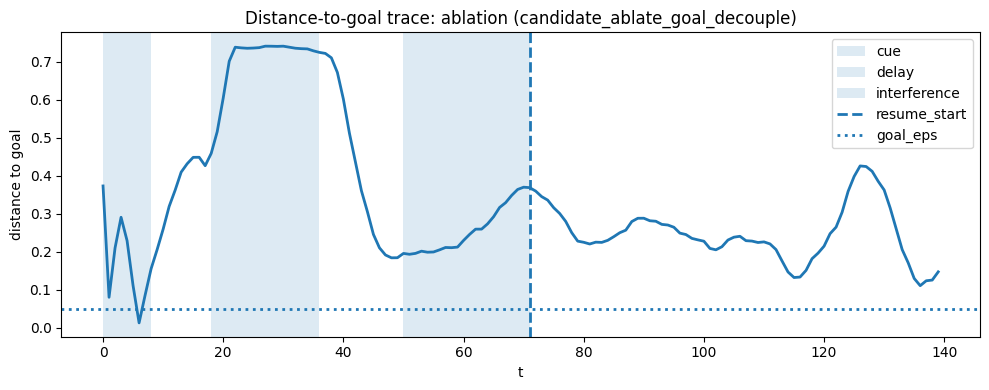

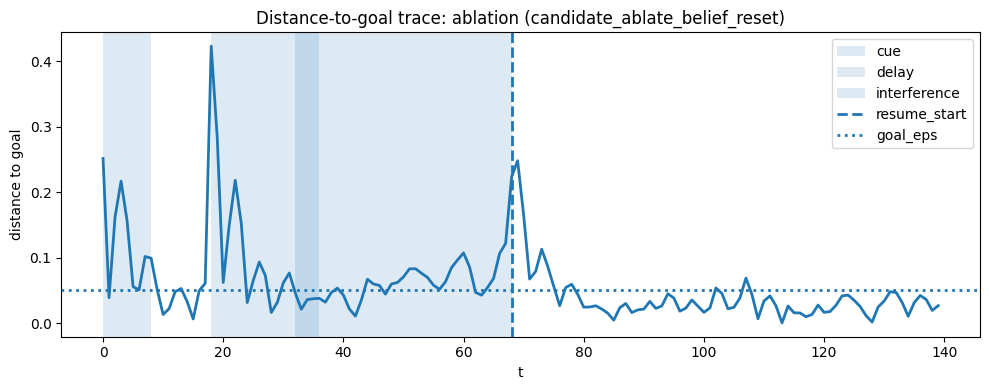

In [ ]:
def plot_trace(seed: int, agent_name: str, title: str, fname: str):
    out = traces[(seed, agent_name)]
    dist = out["dist"]
    spec = out["spec"]

    t = np.arange(len(dist))
    plt.figure(figsize=(10, 4))
    plt.plot(t, dist, linewidth=2)

    plt.axvspan(0, spec.cue_len, alpha=0.15, label="cue")
    plt.axvspan(spec.delay_start, spec.delay_end, alpha=0.15, label="delay")
    plt.axvspan(spec.interfere_start, spec.interfere_end, alpha=0.15, label="interference")
    plt.axvline(spec.resume_start, linestyle="--", linewidth=2, label="resume_start")
    plt.axhline(EPS_GOAL, linestyle=":", linewidth=2, label="goal_eps")

    plt.title(title)
    plt.xlabel("t")
    plt.ylabel("distance to goal")
    plt.legend(loc="upper right")
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(os.path.join(FIG_DIR, fname), dpi=160)
    plt.show()


seed0 = SEEDS[0]
plot_trace(seed0, "candidate_level3",
           "Distance-to-goal trace: candidate (Level-3)",
           "fig_trace_candidate.png")

for b in ["reactive_nomemory", "heading_script", "default_attractor"]:
    plot_trace(seed0, b, f"Distance-to-goal trace: baseline ({b})", f"fig_trace_{b}.png")

if ENABLE_ABLATIONS:
    for a in ["candidate_ablate_goal_scramble", "candidate_ablate_goal_decouple", "candidate_ablate_belief_reset"]:
        plot_trace(seed0, a, f"Distance-to-goal trace: ablation ({a})", f"fig_trace_{a}.png")


## 8) 2D trajectory (one episode)


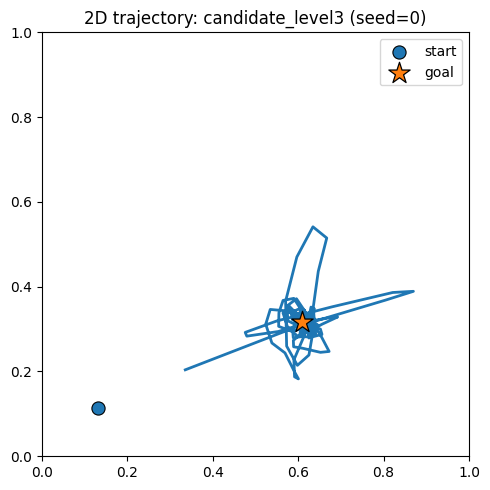

In [ ]:
def plot_trajectory_2d(seed: int, agent_name: str, fname: str):
    out = traces[(seed, agent_name)]
    ps = out["ps"]
    spec = out["spec"]

    plt.figure(figsize=(5, 5))

    # Plot trajectory underneath markers
    plt.plot(ps[:, 0], ps[:, 1], linewidth=2, zorder=1)

    # Plot start/goal above the line so they can't be hidden
    plt.scatter([spec.p0[0]], [spec.p0[1]],
                marker="o", s=90, label="start",
                zorder=4, edgecolors="k", linewidths=0.8)

    plt.scatter([spec.goal[0]], [spec.goal[1]],
                marker="*", s=260, label="goal",
                zorder=6, edgecolors="k", linewidths=0.9)

    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.title(f"2D trajectory: {agent_name} (seed={seed})")

    # Move legend away from top-right to reduce chance of covering the goal
    plt.legend(loc="upper right")

    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(os.path.join(FIG_DIR, fname), dpi=160)
    plt.show()


plot_trajectory_2d(SEEDS[0], "candidate_level3", "fig_traj2d_candidate.png")


## 9) Export note (figures directory)


In [ ]:
print(f"Saved figures to: {FIG_DIR}/ (SAVE_FIGS={SAVE_FIGS})")
if SAVE_FIGS:
    for fn in sorted(os.listdir(FIG_DIR)):
        print(" -", fn)


---

### Notes for the paper (how to interpret outputs)
- The key validity adjustment is that **success is only counted post-resume** (after delay + interference).
- Expected Level-3 signature:
  - Candidate shows higher **post-resume success**, better **persistence ratio**, lower **resumption latency** than baselines.
  - **Goal-scramble / goal-decouple** ablations collapse performance toward baseline.
  - **Belief reset at resume** increases latency and reduces persistence, especially with wall masking.
